In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
import timm
from tqdm.notebook import tqdm
import mlflow


from src.config import EXTERNAL_DATA_DIR, Settings as s

# Types
from pathlib import Path

In [14]:
TRAIN_IMAGE_DIR = EXTERNAL_DATA_DIR / 'cards-image-datasetclassification' / 'train'

In [15]:
class PlayingCardDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = ImageFolder(data, transform=transform)

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index]

In [16]:
dataset: ImageFolder = PlayingCardDataset(TRAIN_IMAGE_DIR)

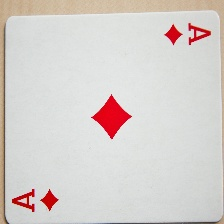

In [17]:
image, label = dataset[120]
image

In [18]:
{v:k for k, v in  dataset.data.class_to_idx.items()}

{0: 'ace of clubs',
 1: 'ace of diamonds',
 2: 'ace of hearts',
 3: 'ace of spades',
 4: 'eight of clubs',
 5: 'eight of diamonds',
 6: 'eight of hearts',
 7: 'eight of spades',
 8: 'five of clubs',
 9: 'five of diamonds',
 10: 'five of hearts',
 11: 'five of spades',
 12: 'four of clubs',
 13: 'four of diamonds',
 14: 'four of hearts',
 15: 'four of spades',
 16: 'jack of clubs',
 17: 'jack of diamonds',
 18: 'jack of hearts',
 19: 'jack of spades',
 20: 'joker',
 21: 'king of clubs',
 22: 'king of diamonds',
 23: 'king of hearts',
 24: 'king of spades',
 25: 'nine of clubs',
 26: 'nine of diamonds',
 27: 'nine of hearts',
 28: 'nine of spades',
 29: 'queen of clubs',
 30: 'queen of diamonds',
 31: 'queen of hearts',
 32: 'queen of spades',
 33: 'seven of clubs',
 34: 'seven of diamonds',
 35: 'seven of hearts',
 36: 'seven of spades',
 37: 'six of clubs',
 38: 'six of diamonds',
 39: 'six of hearts',
 40: 'six of spades',
 41: 'ten of clubs',
 42: 'ten of diamonds',
 43: 'ten of hear

In [19]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = PlayingCardDataset(TRAIN_IMAGE_DIR, transform=transform)

In [20]:
data = DataLoader(dataset, batch_size=32, shuffle=True)
data

In [21]:
for images, labels in data:
    print(images, labels)
    break


tensor([[[[0.9451, 0.9373, 0.9373,  ..., 0.9647, 0.9412, 0.9490],
          [0.9333, 0.9333, 0.9333,  ..., 0.9686, 0.9451, 0.9373],
          [0.9294, 0.9333, 0.9412,  ..., 0.9686, 0.9490, 0.9412],
          ...,
          [0.9412, 0.9412, 0.9412,  ..., 0.9490, 0.9490, 0.9412],
          [0.9373, 0.9373, 0.9373,  ..., 0.9451, 0.9412, 0.9333],
          [0.9412, 0.9373, 0.9373,  ..., 0.9373, 0.9294, 0.9412]],

         [[0.9412, 0.9333, 0.9373,  ..., 0.9647, 0.9412, 0.9490],
          [0.9412, 0.9412, 0.9412,  ..., 0.9686, 0.9451, 0.9373],
          [0.9412, 0.9412, 0.9451,  ..., 0.9686, 0.9490, 0.9412],
          ...,
          [0.9412, 0.9412, 0.9412,  ..., 0.9451, 0.9451, 0.9490],
          [0.9373, 0.9373, 0.9373,  ..., 0.9412, 0.9373, 0.9412],
          [0.9412, 0.9373, 0.9373,  ..., 0.9333, 0.9333, 0.9451]],

         [[0.9412, 0.9373, 0.9373,  ..., 0.9647, 0.9412, 0.9490],
          [0.9373, 0.9373, 0.9373,  ..., 0.9686, 0.9451, 0.9373],
          [0.9373, 0.9373, 0.9412,  ..., 0

# Model Init

In [22]:
class PlayingCardClassifier(nn.Module):
    def __init__(self, num_classes=53):
        super(PlayingCardClassifier, self).__init__()
        self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])  # Remove the last layer

        enet_out_size = 1280

        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(enet_out_size, num_classes))


    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Model Training

## Setup Data

In [23]:
IMAGE_DIR: Path = EXTERNAL_DATA_DIR / 'cards-image-datasetclassification'

train_folder = IMAGE_DIR / 'train'
validation_folder = IMAGE_DIR / 'valid'
test_folder = IMAGE_DIR / 'test'


train_dataset = PlayingCardDataset(train_folder, transform=transform)
validation_dataset = PlayingCardDataset(validation_folder, transform=transform)
test_dataset = PlayingCardDataset(test_folder, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [33]:
import mlflow.pytorch

mlflow.set_tracking_uri(uri="http://192.168.100.203:5000/")
mlflow.set_experiment("[P] Playing Card Classification")

EPOCHS: int = 10
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

model = PlayingCardClassifier(num_classes=len(dataset.data.classes))
device: torch.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

params = {
    "num_classes": len(dataset.data.classes),
    "learning_rate": 0.001,
    "epochs": EPOCHS,
    "batch_size": train_loader.batch_size,
    "optimizer": "Adam",
    "model": "timm.efficientnet_b0",
    "device": str(device),
}


with mlflow.start_run(log_system_metrics=True) as run:
    mlflow.log_params(params)
    mlflow.set_tag("purpose", "practice")
    mlflow.set_tag("framework", "pytorch")
    mlflow.set_tag("task", "classification")
    for epoch in tqdm(range(EPOCHS), desc="Training epochs"):
        model.train()
        running_loss = 0.0
        correct_samples = 0
        total_samples = 0


        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} - Training batches", leave=False):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs: torch.Tensor = model(images)
            loss: torch.Tensor = criterion(outputs, labels)
            assert isinstance(loss, torch.Tensor), "Loss should be a torch.Tensor"
            assert loss.dim() == 0, "Loss should be a scalar tensor"
            # print(f"Loss: {loss}")
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)  # returns a tuple (values, indices)
            correct_samples += (predicted == labels).sum().item()  # returns an int
            total_samples += labels.size(0)  # returns an int

        train_loss: float = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)
        train_accuracy: float = correct_samples / total_samples
        train_accuracies.append(train_accuracy)

        model.eval()
        running_val_loss = 0.0
        correct_samples = 0
        total_samples = 0
        with torch.no_grad():
            for images, labels in tqdm(validation_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} - Validation batches", leave=False):
                images, labels = images.to(device), labels.to(device)

                outputs: torch.Tensor = model(images)
                loss: torch.Tensor = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)

                _, predicted = torch.max(
                    outputs, 1
                )  # returns a tuple (values, indices)
                correct_samples += (predicted == labels).sum().item()  # returns an int
                total_samples += labels.size(0)  # returns an int

        val_loss: float = running_val_loss / len(validation_loader.dataset)
        val_losses.append(val_loss)
        val_accuracy: float = correct_samples / total_samples
        val_accuracies.append(val_accuracy)

        mlflow.log_metrics(
            {
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_accuracy": train_accuracy,
                "val_accuracy": val_accuracy,
            },
            step=epoch,
        )

    mlflow.pytorch.log_model(model, name="model")
    mlflow.get_run(run.info.run_id)

2025/06/30 21:40:47 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2025/06/30 21:40:47 WARNING mlflow.system_metrics.metrics.gpu_monitor: Encountered error Not Supported when trying to collect GPU power usage metrics.


Training epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 - Training batches:   0%|          | 0/239 [00:00<?, ?it/s]

2025/06/30 21:40:57 WARNING mlflow.system_metrics.metrics.gpu_monitor: Encountered error Not Supported when trying to collect GPU power usage metrics.
2025/06/30 21:41:07 WARNING mlflow.system_metrics.metrics.gpu_monitor: Encountered error Not Supported when trying to collect GPU power usage metrics.
2025/06/30 21:41:17 WARNING mlflow.system_metrics.metrics.gpu_monitor: Encountered error Not Supported when trying to collect GPU power usage metrics.
2025/06/30 21:41:27 WARNING mlflow.system_metrics.metrics.gpu_monitor: Encountered error Not Supported when trying to collect GPU power usage metrics.
2025/06/30 21:41:37 WARNING mlflow.system_metrics.metrics.gpu_monitor: Encountered error Not Supported when trying to collect GPU power usage metrics.


Epoch 1/10 - Validation batches:   0%|          | 0/9 [00:00<?, ?it/s]

...

Epoch 10/10 - Training batches:   0%|          | 0/239 [00:00<?, ?it/s]

2025/06/30 21:48:28 WARNING mlflow.system_metrics.metrics.gpu_monitor: Encountered error Not Supported when trying to collect GPU power usage metrics.
2025/06/30 21:48:38 WARNING mlflow.system_metrics.metrics.gpu_monitor: Encountered error Not Supported when trying to collect GPU power usage metrics.
2025/06/30 21:48:48 WARNING mlflow.system_metrics.metrics.gpu_monitor: Encountered error Not Supported when trying to collect GPU power usage metrics.
2025/06/30 21:48:58 WARNING mlflow.system_metrics.metrics.gpu_monitor: Encountered error Not Supported when trying to collect GPU power usage metrics.
2025/06/30 21:49:08 WARNING mlflow.system_metrics.metrics.gpu_monitor: Encountered error Not Supported when trying to collect GPU power usage metrics.


Epoch 10/10 - Validation batches:   0%|          | 0/9 [00:00<?, ?it/s]

2025/06/30 21:49:18 WARNING mlflow.system_metrics.metrics.gpu_monitor: Encountered error Not Supported when trying to collect GPU power usage metrics.
2025/06/30 21:49:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/06/30 21:49:19 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/06/30 21:49:19 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2025/06/30 21:49:19 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run rare-rat-674 at: http://192.168.100.203:5000/#/experiments/2/runs/dd6d373c227748939b95aecc7c3be260
🧪 View experiment at: http://192.168.100.203:5000/#/experiments/2


# Evaluation

In [ ]:
model.to(device)  # Move model back to device for testing
model.eval()
correct_samples = 0
total_samples = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing batches"):
        images, labels = images.to(device), labels.to(device)
        
        outputs: torch.Tensor = model(images)
        _, predicted = torch.max(outputs, 1) # returns a tuple (values, indices)
        correct_samples += (predicted == labels).sum().item() # returns an int
        total_samples += labels.size(0)

test_accuracy: float = correct_samples / total_samples
print(f"Test Accuracy: {test_accuracy:.4f}")

Testing batches:   0%|          | 0/9 [00:00<?, ?it/s]

Test Accuracy: 0.9245


<Axes: >

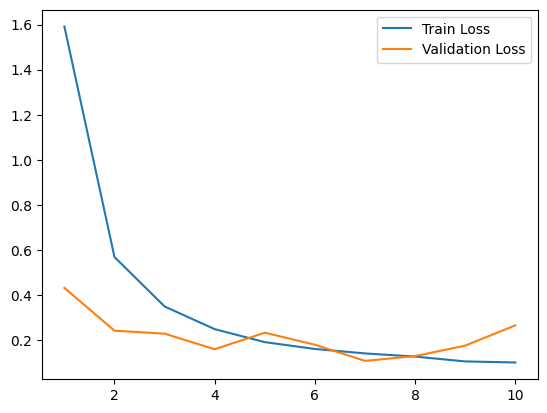

In [ ]:
import seaborn as sns

sns.lineplot(x=range(1, EPOCHS + 1), y=train_losses, label='Train Loss')
sns.lineplot(x=range(1, EPOCHS + 1), y=val_losses, label='Validation Loss')

<Axes: >

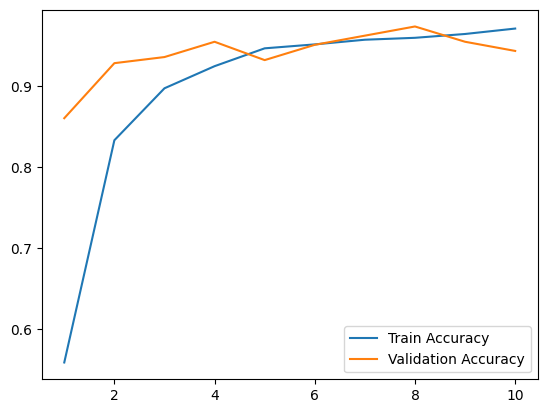

In [ ]:
sns.lineplot(x=range(1, EPOCHS + 1), y=train_accuracies, label='Train Accuracy')
sns.lineplot(x=range(1, EPOCHS + 1), y=val_accuracies, label='Validation Accuracy')